# Figure 2

Daily AOD anomaly maps between clean and polluted simulatings, from few days before WAI up to event.

In [13]:
import xarray as xr
import datetime as dt
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors, colormaps
import cartopy.crs as ccrs
import datetime as dt
import pandas as pd
import numpy as np
import string
import utils

# Read model output and MOSAiC coordinates

In [12]:
aod = xr.open_dataset("/mnt/data/model_output/thompson_derived_variables/aod_2020-04-13_2020-04-17.nc")
aod = aod.assign_coords({"day": ("Time",[T.dt.day for T in aod.Time])})
mosaic = xr.open_dataset("/mnt/data/mosaic_nav/mosaic_coords_2020-04.nc")
mosaic = mosaic.assign_coords({"day": ("time", [T.dt.day for T in mosaic.time])})

aod = aod.groupby(aod.day).mean()
mosaic = mosaic.groupby(mosaic.day).mean()
mosaic = mosaic.sel(day=aod.day.values)

aod_anom = aod.isel(simulation=aod.pollution_state=="polluted").squeeze() - aod.isel(simulation=aod.pollution_state=="clean").squeeze()


# Plot

In [27]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2



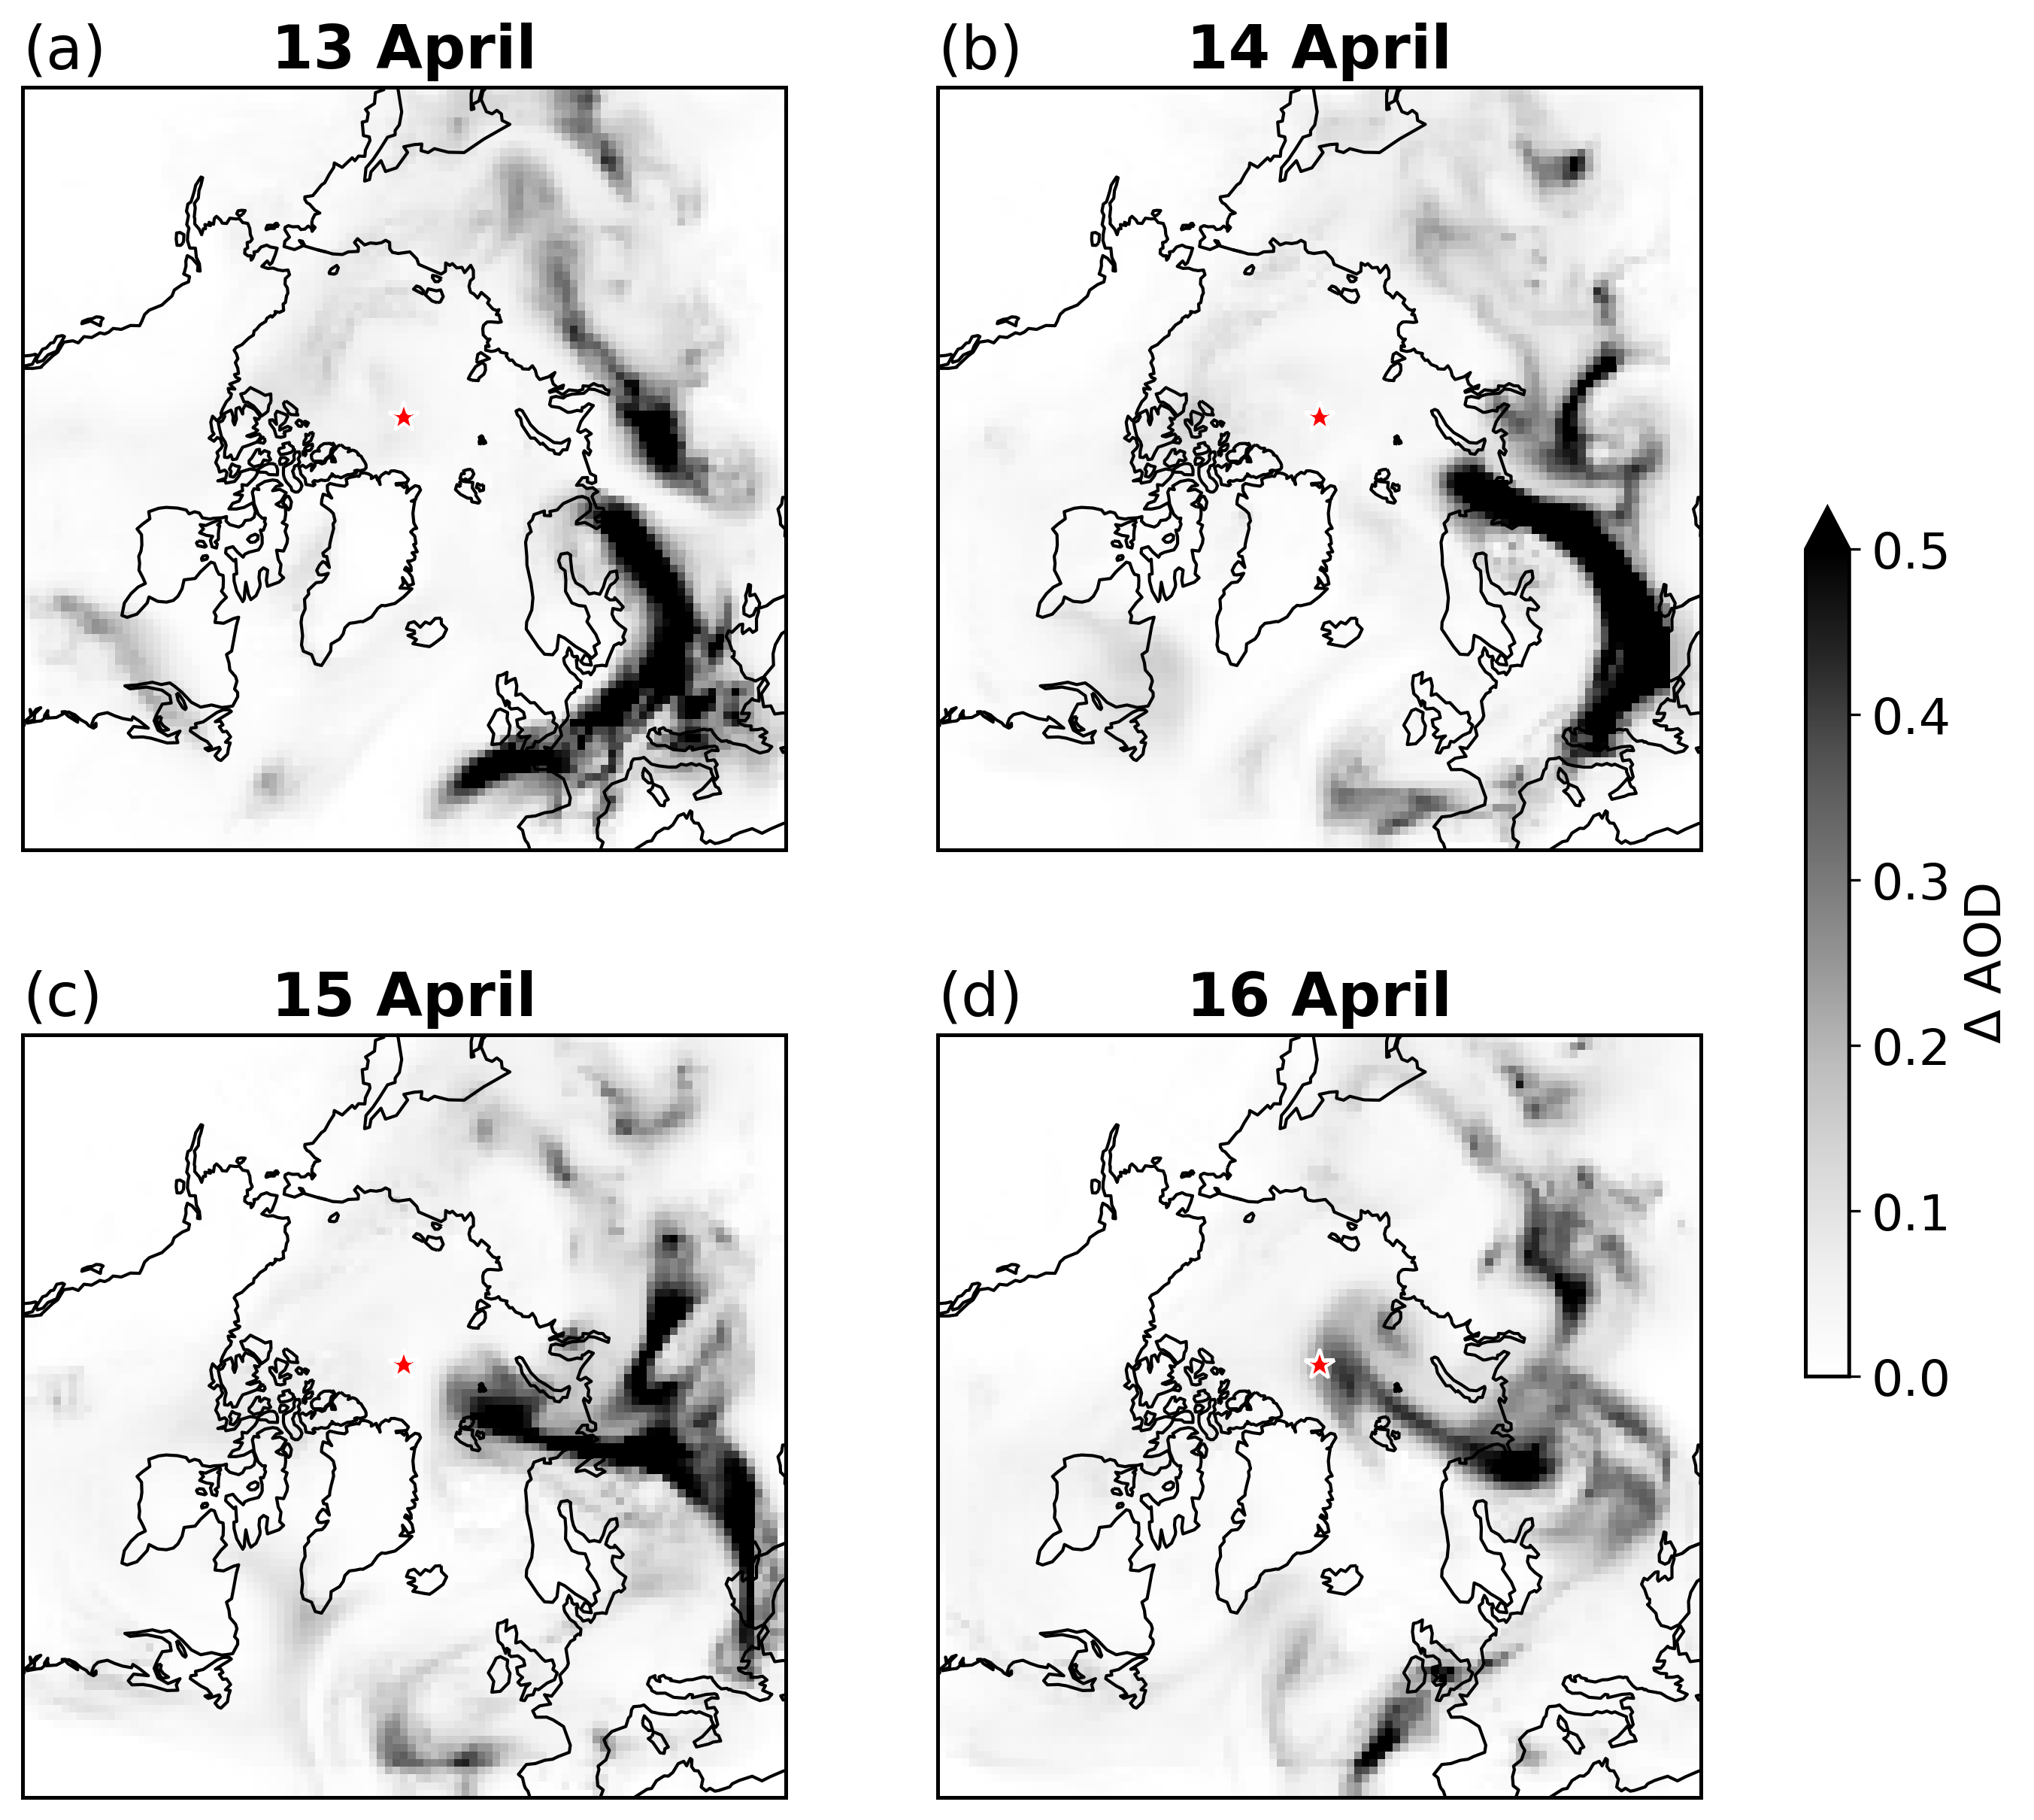

In [34]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-25)},
    dpi=300
)
for ax in axes.flatten():
    ax.coastlines()
for i in range(4):
    ax = axes.flatten()[i]
    day = aod_anom.day.values[i]
    ds = aod_anom.aod550.isel(day=i).squeeze()
    mesh = ax.pcolormesh(
        ds.longitude,
        ds.latitude,
        ds,
        transform=ccrs.PlateCarree(),
        vmin=0, vmax=0.5,
        cmap="Greys",
    )
    ax.plot(
        mosaic.isel(day=i).Longitude,
        mosaic.isel(day=i).Latitude,
        marker="*",
        mec="white",
        mfc="red",
        ms=10
    )
    ax.set_title(f"{day} April", weight="bold")
    ax.set_title(f"({string.ascii_lowercase[i]})", loc="left")
plt.colorbar(mesh, ax=axes, label='$\\Delta$ AOD', shrink=0.5, extend="max")
plt.savefig(f"figures/figure2.png", bbox_inches="tight")